In [1]:
import os
import random
from sklearn.model_selection import train_test_split
from data_reader import MaldiDataset
import numpy as np
from scipy.spatial.distance import euclidean
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [2]:
# Set all seeds to make the results reproducible
random.seed(42)
np.random.seed(42)


# This script is a simple starting point to classify fungal data using MALDI-TOF spectra.
class SimpleFungusDataLoader:
    def __init__(self, dataset_path, test_size=0.2, random_state=42):
        # Initialize the classifier with dataset path, test size, and random state for reproducibility.
        self.dataset_path = dataset_path
        self.test_size = test_size
        self.random_state = random_state
        self.data = None
        self.train_data = []
        self.test_data = []

    def load_data(self, n_step):
        # Load the dataset using MaldiDataset
        dataset = MaldiDataset(self.dataset_path, n_step=n_step)
        dataset.parse_dataset()  # Parse the dataset from the specified path
        self.data = dataset.get_data()  # Retrieve the parsed data


    def split_data_stratify(self):
        """
        Divide los datos en train y test de forma estratificada según 'genus_species_label',
        asegurando que no haya solapamiento de 'unique_id_label' entre ambos conjuntos.
        Las clases con menos de 2 instancias se asignan directamente al conjunto de entrenamiento.
        """
        # Convertir los datos en un DataFrame
        df = pd.DataFrame(self.data)

        # Agrupar por 'unique_id_label' y seleccionar una clase representativa ('genus_species_label') para cada grupo
        unique_id_groups = df.groupby('unique_id_label').first().reset_index()

        # Identificar las clases con menos de 2 instancias
        class_counts = unique_id_groups['genus_species_label'].value_counts()
        small_classes = class_counts[class_counts < 2].index

        # Separar los grupos con clases pequeñas y el resto
        small_class_groups = unique_id_groups[unique_id_groups['genus_species_label'].isin(small_classes)]
        remaining_groups = unique_id_groups[~unique_id_groups['genus_species_label'].isin(small_classes)]

        # Estratificar las clases restantes
        train_ids, test_ids = train_test_split(
            remaining_groups['unique_id_label'],
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=remaining_groups['genus_species_label']  # Usar 'genus_species_label' como criterio de estratificación
        )

        # Agregar todas las instancias de clases pequeñas al conjunto de entrenamiento
        train_ids = pd.concat([pd.Series(train_ids), small_class_groups['unique_id_label']])

        # Filtrar el DataFrame original para crear los conjuntos de train y test
        self.train_data = df[df['unique_id_label'].isin(train_ids)]  # DataFrame de entrenamiento
        self.test_data = df[df['unique_id_label'].isin(test_ids)]  # DataFrame de prueba

        # Verificar que no haya solapamiento de 'unique_id_label' entre train y test
        train_unique_ids = set(self.train_data['unique_id_label'])
        test_unique_ids = set(self.test_data['unique_id_label'])
        assert len(train_unique_ids.intersection(test_unique_ids)) == 0, "Unique ID labels overlap between train and test"

        # Imprimir estadísticas
        print(f"Number of unique_id_labels in train data: {len(train_unique_ids)}")
        print(f"Number of unique_id_labels in test data: {len(test_unique_ids)}")
        print(f"Number of samples in train data: {len(self.train_data)}")
        print(f"Number of samples in test data: {len(self.test_data)}")
        print(f"Number of classes to predict: {len(self.train_data['genus_species_label'].unique())}")



    def plot_data_distribution(self):
        """
        Grafica la distribución de las clases ('genus_species_label') en los conjuntos de
        entrenamiento y prueba para visualizar las proporciones después de la división estratificada.
        """
        # Contar las etiquetas en los conjuntos de entrenamiento y prueba
        train_counts = self.train_data['genus_species_label'].value_counts()
        test_counts = self.test_data['genus_species_label'].value_counts()

        # Unificar las etiquetas para asegurar que ambas series tengan los mismos índices
        all_labels = pd.Index(train_counts.index).union(test_counts.index)
        train_counts = train_counts.reindex(all_labels, fill_value=0)
        test_counts = test_counts.reindex(all_labels, fill_value=0)

        # Crear gráfico
        x = np.arange(len(all_labels))  # Posiciones de las barras
        width = 0.4  # Ancho de las barras

        plt.figure(figsize=(14, 8))  # Tamaño del gráfico
        plt.bar(x - width / 2, train_counts, width, label='Train', alpha=0.8, color='blue')
        plt.bar(x + width / 2, test_counts, width, label='Test', alpha=0.8, color='orange')

        # Configurar etiquetas y título
        plt.xlabel('Genus+Species Label', fontsize=12)
        plt.ylabel('Number of Samples', fontsize=12)
        plt.title('Distribution of Genus+Species Labels in Train and Test Data', fontsize=14)
        plt.xticks(x, all_labels, rotation=90, fontsize=10)  # Etiquetas en el eje X
        plt.legend(fontsize=12)

        # Ajustar diseño
        plt.tight_layout()
        plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    def get_train_data(self):
        return self.train_data
    
    def get_test_data(self):
        return self.test_data

In [3]:
# Define the dataset path (update this path to where your dataset is located)
dataset_path = "data/fungus_db"

# Initialize the classifier with the dataset path
fungus_identifier = SimpleFungusDataLoader(dataset_path)

fungus_identifier.load_data(n_step=3)

# Load and split the data into training and test sets.
fungus_identifier.split_data_stratify()

c:\Users\aleja\OneDrive\Documentos\TFM\FungusClassifier\data_reader.py:299: RuntimeWarning: invalid value encountered in divide
  intensity=SpectrumObj.intensity / SpectrumObj.intensity.sum() * self.sum,


Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Skipping nan spectrum
Number of unique_id_labels in train data: 268
Number of unique_id_labels in test data: 64
Number of samples in train data: 6452
Number of samples in test data: 1476
Number of classes to predict: 60


In [4]:
train_data = fungus_identifier.get_train_data()
test_data = fungus_identifier.get_test_data()

In [5]:
train_data['spectrum']

0       [0.0006368922029347907, 0.0016267279888776424,...
1       [0.0005741010153235321, 0.0015172147338552698,...
2       [0.0005715951632251119, 0.0008641715668822096,...
3       [0.0006000316540783796, 0.0012279536892089275,...
4       [0.0006245605310904966, 0.0016598431383008756,...
                              ...                        
7923    [0.0007720234181554094, 0.00034623210894109755...
7924    [0.0008468689975809885, 0.0003927569137581299,...
7925    [0.0007586675036937004, 0.0002650907625350964,...
7926    [0.0008696535900660974, 0.0004968936683348655,...
7927    [0.0008182921135792377, 0.0003572187484178759,...
Name: spectrum, Length: 6452, dtype: object

In [6]:
label_encoder_genus = LabelEncoder()
label_encoder_genus_species = LabelEncoder()
train_data['genus_species_label'] = label_encoder_genus_species.fit_transform(train_data['genus_species_label'])
train_data['genus_label'] = label_encoder_genus.fit_transform(train_data['genus_label'])
test_data['genus_species_label'] = label_encoder_genus_species.transform(test_data['genus_species_label'])
test_data['genus_label'] = label_encoder_genus.transform(test_data['genus_label'])

spectra_normalized = []
for spectrum in train_data['spectrum']:
    scaler = StandardScaler()
    # Asegurar que el spectrum sea un array 2D
    spectrum_2d = np.array(spectrum).reshape(-1, 1)
    spectrum_2d = spectrum_2d * 1e4
    spectrum_normalized = scaler.fit_transform(spectrum_2d).flatten()  # Reducir a 1D nuevamente
    spectra_normalized.append(spectrum_normalized)
train_data['spectrum'] = spectra_normalized

spectra_normalized = []
for spectrum in test_data['spectrum']:
    scaler = StandardScaler()
    # Asegurar que el spectrum sea un array 2D
    spectrum_2d = np.array(spectrum).reshape(-1, 1)
    spectrum_2d = spectrum_2d * 1e4
    spectrum_normalized = scaler.fit_transform(spectrum_2d).flatten()  # Reducir a 1D nuevamente
    spectra_normalized.append(spectrum_normalized)
test_data['spectrum'] = spectra_normalized

In [7]:
x_train = train_data.drop(columns=['genus_species_label', 'genus_label', 'unique_id_label','m/z'])
genus_label_train = train_data['genus_label']
genus_species_label_train = train_data['genus_species_label']
x_test = test_data.drop(columns=['genus_species_label', 'genus_label', 'unique_id_label','m/z'])
genus_label_test = test_data['genus_label']
genus_species_label_test = test_data['genus_species_label']

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def evaluate_knn_classifier(x_test, y_test, knn_classifier, classes=None, figsize=(20, 20), fontsize=8, zero_division=0):
    """
    Evalúa un clasificador KNN en datos de prueba e incluye métricas detalladas,
    además de graficar la matriz de confusión sin la barra de color (colorbar).
    """
    # Predicciones del clasificador
    y_pred = knn_classifier.predict(x_test)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    print(f"KNN Classifier Accuracy: {accuracy:.2f}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_test, 
            y_pred, 
            target_names=classes, 
            zero_division=zero_division  # Evitar el warning
        )
    )
    
    # Generar la matriz de confusión (solo con las clases presentes en y_test e y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print("\nConfusion Matrix:")
    print(cm)
    
    # Obtener etiquetas reales del clasificador (todas las clases vistas en el entrenamiento)
    real_class_labels = knn_classifier.classes_
    
    # Identificar las clases presentes en el conjunto de prueba/predicciones
    unique_classes_in_test = np.unique(np.concatenate((y_test, y_pred)))
    
    # Filtrar etiquetas reales para mostrar solo las clases presentes en la matriz de confusión
    display_labels = [str(label) for label in real_class_labels if label in unique_classes_in_test]
    
    # Graficar la matriz de confusión sin la barra de color
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)  # Aquí desactivamos la barra de color
    
    # Ajustar etiquetas y título
    plt.xticks(fontsize=fontsize, rotation=90)
    plt.yticks(fontsize=fontsize)
    plt.title("Confusion Matrix", fontsize=fontsize + 4)
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'predicted_labels': y_pred,
        'true_labels': y_test
    }


In [11]:
spectrum = np.array(train_data['spectrum'].tolist())
spectrum_test = np.array(test_data['spectrum'].tolist())

# BASELINE: KNN

## Aplicando grid search en busca de los mejores híper parámetros

In [12]:
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
    'algorithm': ['auto','ball_tree', 'brute']
}

In [13]:
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=4,  # Validación cruzada
    scoring='accuracy',  # Métrica principal
    verbose=3,  # Mostrar progreso
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Ajustar el modelo con los datos ya normalizados
grid_search.fit(spectrum, genus_species_label_train)

# Resultados del mejor modelo
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated Score:", grid_search.best_score_)

Fitting 4 folds for each of 54 candidates, totalling 216 fits
Best Parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best Cross-Validated Score: 0.9592374457532549


In [15]:
knn_best = grid_search.best_estimator_
knn_best.fit(spectrum, genus_species_label_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

---------------------------- EVALUACIÓN A NIVEL DE GÉNERO Y ESPECIE -----------------------------------
KNN Classifier Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.51      0.68        45
           3       1.00      1.00      1.00        67
           6       1.00      1.00      1.00        70
           7       1.00      1.00      1.00        78
           9       1.00      1.00      1.00        43
          10       0.69      1.00      0.82        49
          12       0.68      1.00      0.81        51
          15       1.00      1.00      1.00        26
          17       1.00      1.00      1.00        27
          18       1.00      1.00      1.00        20
          21       0.00      0.00      0.00         0
          22       1.00      1.00      1.00        20
          23       1.00      1.00      1.00       104
          24       1.00      1.

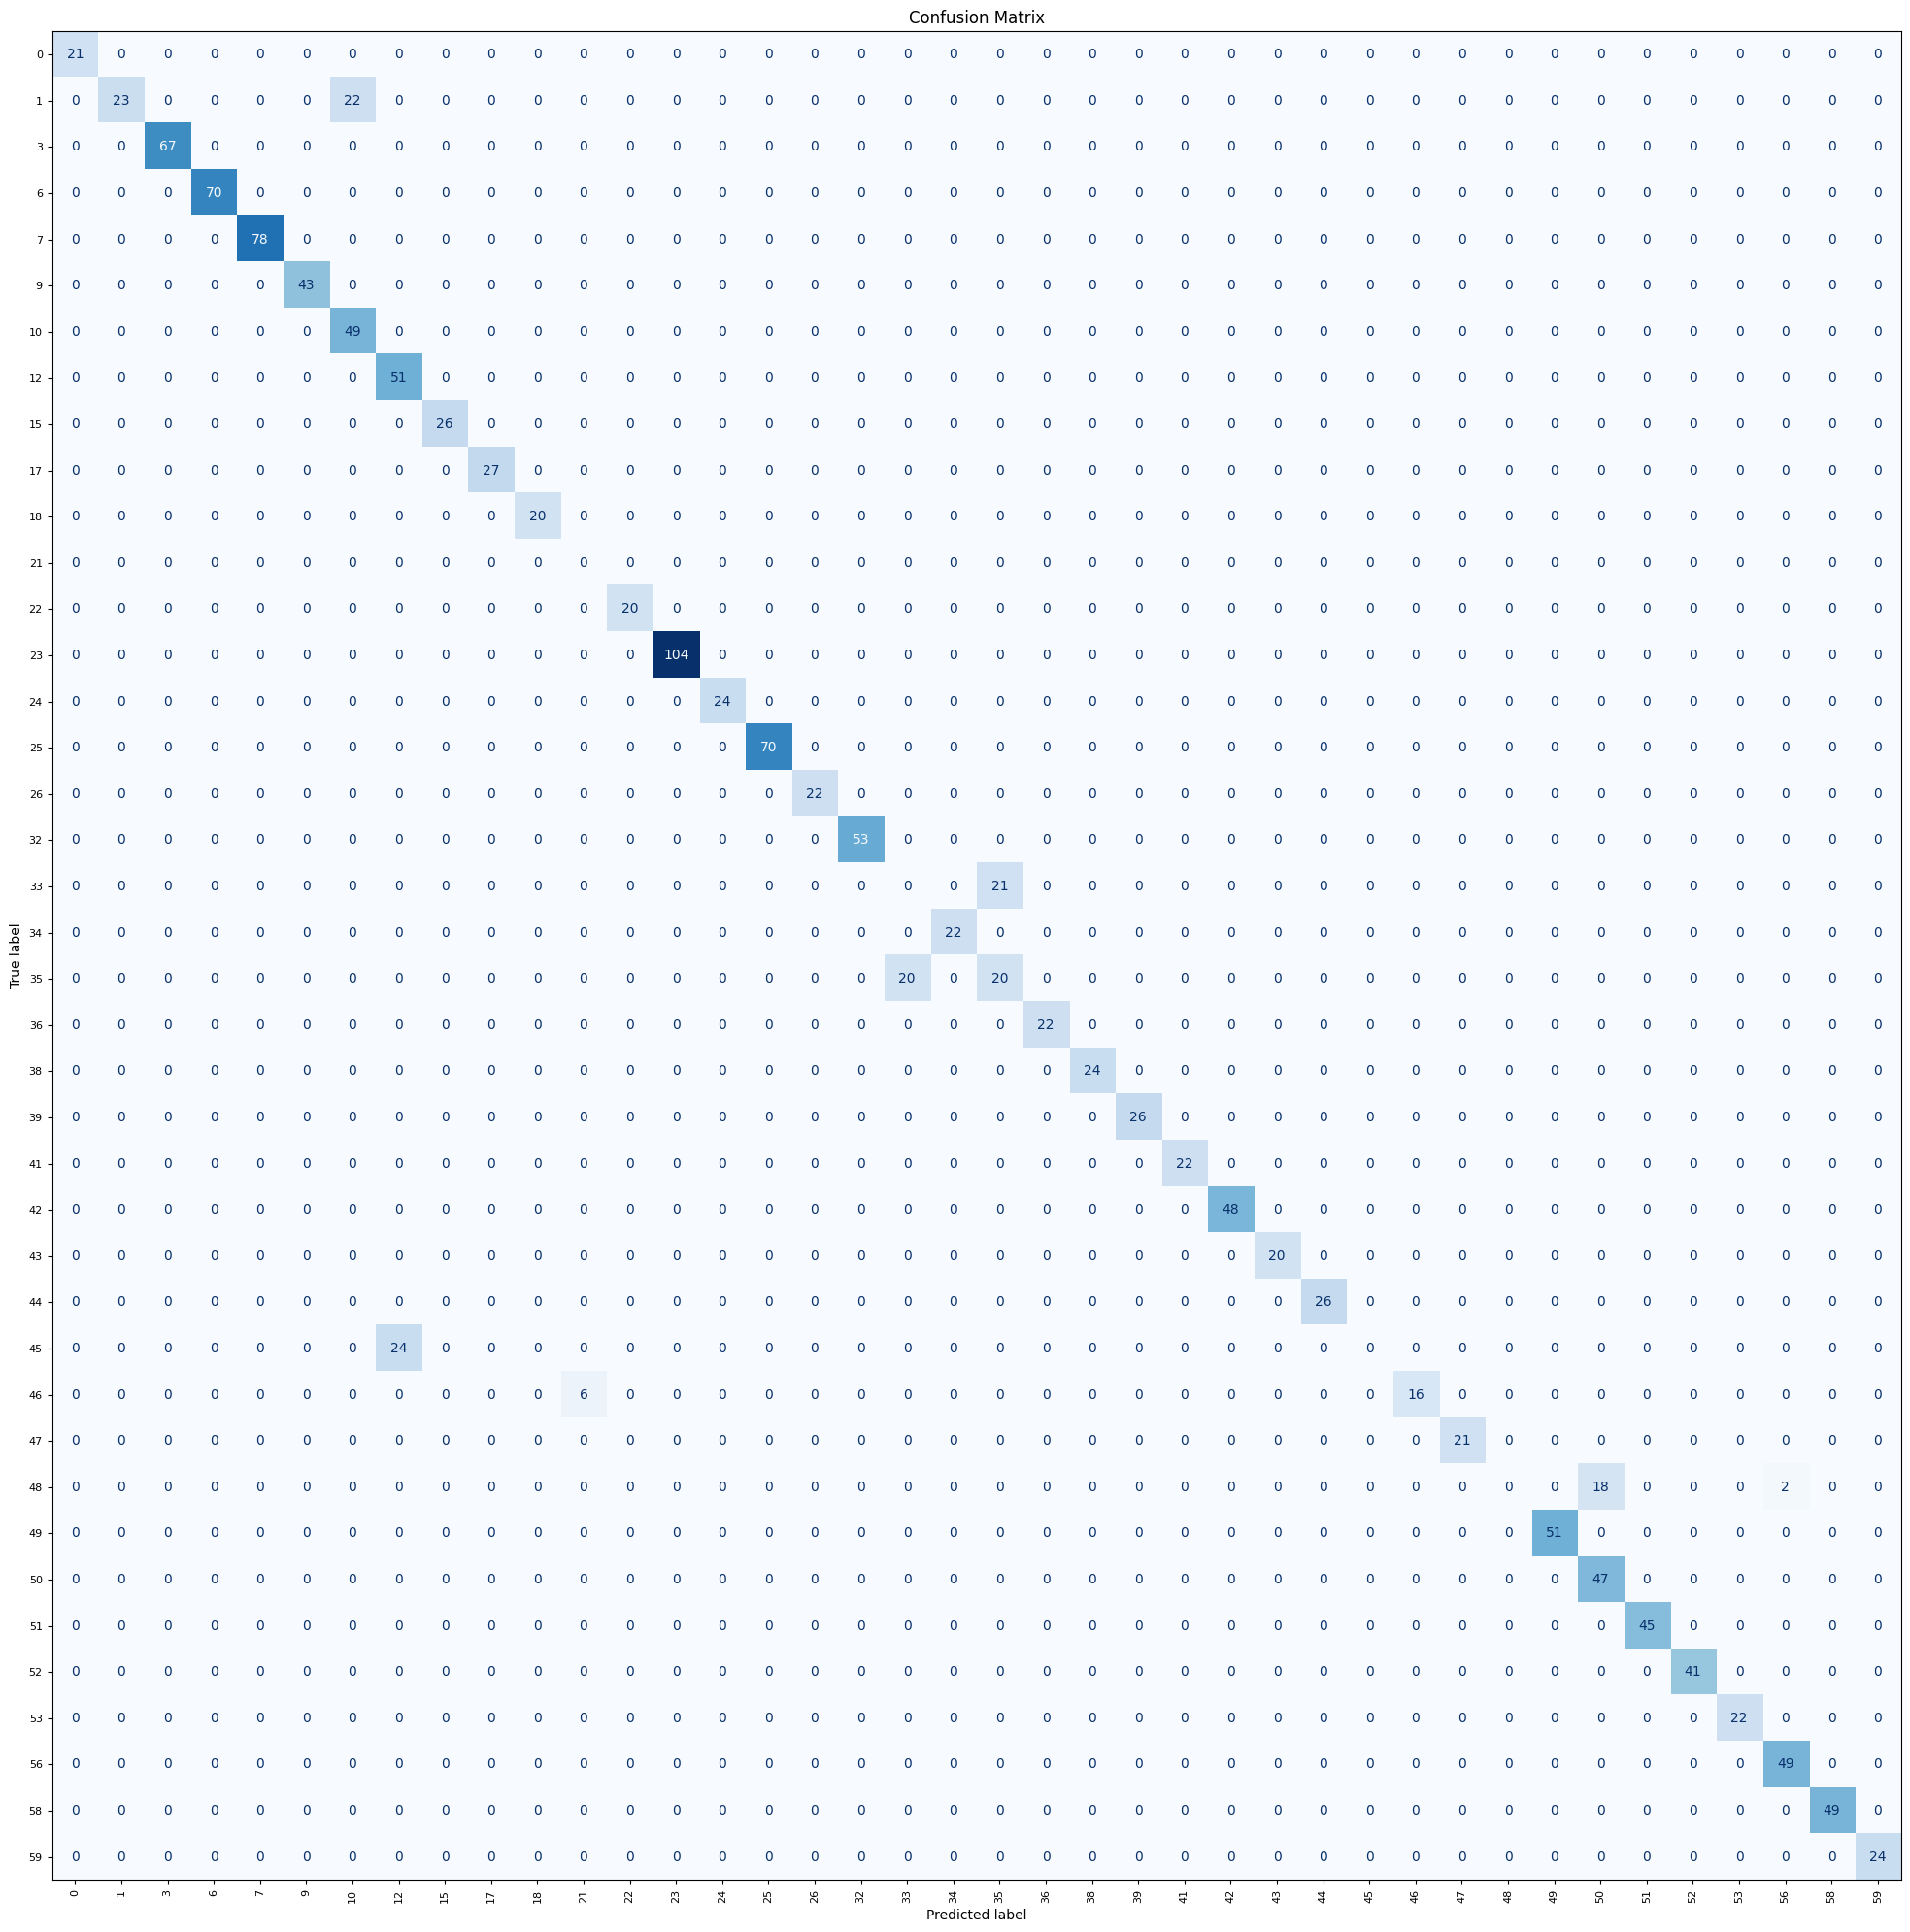

{'accuracy': 0.9234417344173442,
 'predicted_labels': array([ 0,  0,  0, ..., 59, 59, 59]),
 'true_labels': 86       0
 87       0
 88       0
 89       0
 90       0
         ..
 7875    59
 7876    59
 7877    59
 7878    59
 7879    59
 Name: genus_species_label, Length: 1476, dtype: int32}

In [16]:
print("---------------------------- EVALUACIÓN A NIVEL DE GÉNERO Y ESPECIE -----------------------------------")
evaluate_knn_classifier(spectrum_test, genus_species_label_test, knn_best)

## Usando SMOTE

In [17]:
train_data_for_SMOTE = train_data.copy().drop(columns=['genus_species_label', 'genus_label', 'unique_id_label','m/z'])
test_data_for_SMOTE = test_data.copy().drop(columns=['genus_species_label', 'genus_label', 'unique_id_label','m/z'])

In [18]:
spectrum_train_for_SMOTE = np.array(train_data_for_SMOTE['spectrum'].tolist())
smote = SMOTE(random_state=42)
x_train_smote, genus_species_smote = smote.fit_resample(spectrum_train_for_SMOTE, genus_species_label_train)

In [19]:
genus_species_smote_labels = label_encoder_genus_species.inverse_transform(genus_species_smote)
genus_smote_labels = [label.split()[0] for label in genus_species_smote_labels]
genus_smote = label_encoder_genus.transform(genus_smote_labels)

In [20]:
print(label_encoder_genus_species.transform(['Aspergillus fumigatus']))

[6]


## Aplicando grid search en busca de los mejores híper parámetros con SMOTE

In [21]:
param_grid_for_SMOTE = {
    'n_neighbors': [3, 5, 7, ],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
    'algorithm': ['auto','ball_tree', 'brute']
}

In [22]:
grid_search_for_SMOTE = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_for_SMOTE,
    cv=4,  # Validación cruzada
    scoring='accuracy',  # Métrica principal
    verbose=3,  # Mostrar progreso
    n_jobs=-1  # Usar todos los núcleos disponibles
)

grid_search_for_SMOTE.fit(x_train_smote, genus_species_smote)

# Resultados del mejor modelo
print("Best Parameters:", grid_search_for_SMOTE.best_params_)
print("Best Cross-Validated Score:", grid_search_for_SMOTE.best_score_)

Fitting 4 folds for each of 54 candidates, totalling 216 fits
Best Parameters: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validated Score: 1.0


---------------------------- EVALUACIÓN A NIVEL DE GÉNERO Y ESPECIE CON SMOTE -----------------------------------
KNN Classifier Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.24      0.39        45
           3       1.00      1.00      1.00        67
           6       1.00      1.00      1.00        70
           7       1.00      1.00      1.00        78
           9       1.00      1.00      1.00        43
          10       0.59      1.00      0.74        49
          12       1.00      1.00      1.00        51
          15       1.00      1.00      1.00        26
          17       1.00      1.00      1.00        27
          18       1.00      1.00      1.00        20
          20       0.00      0.00      0.00         0
          21       0.00      0.00      0.00         0
          22       1.00      1.00      1.00        20
          23       1.

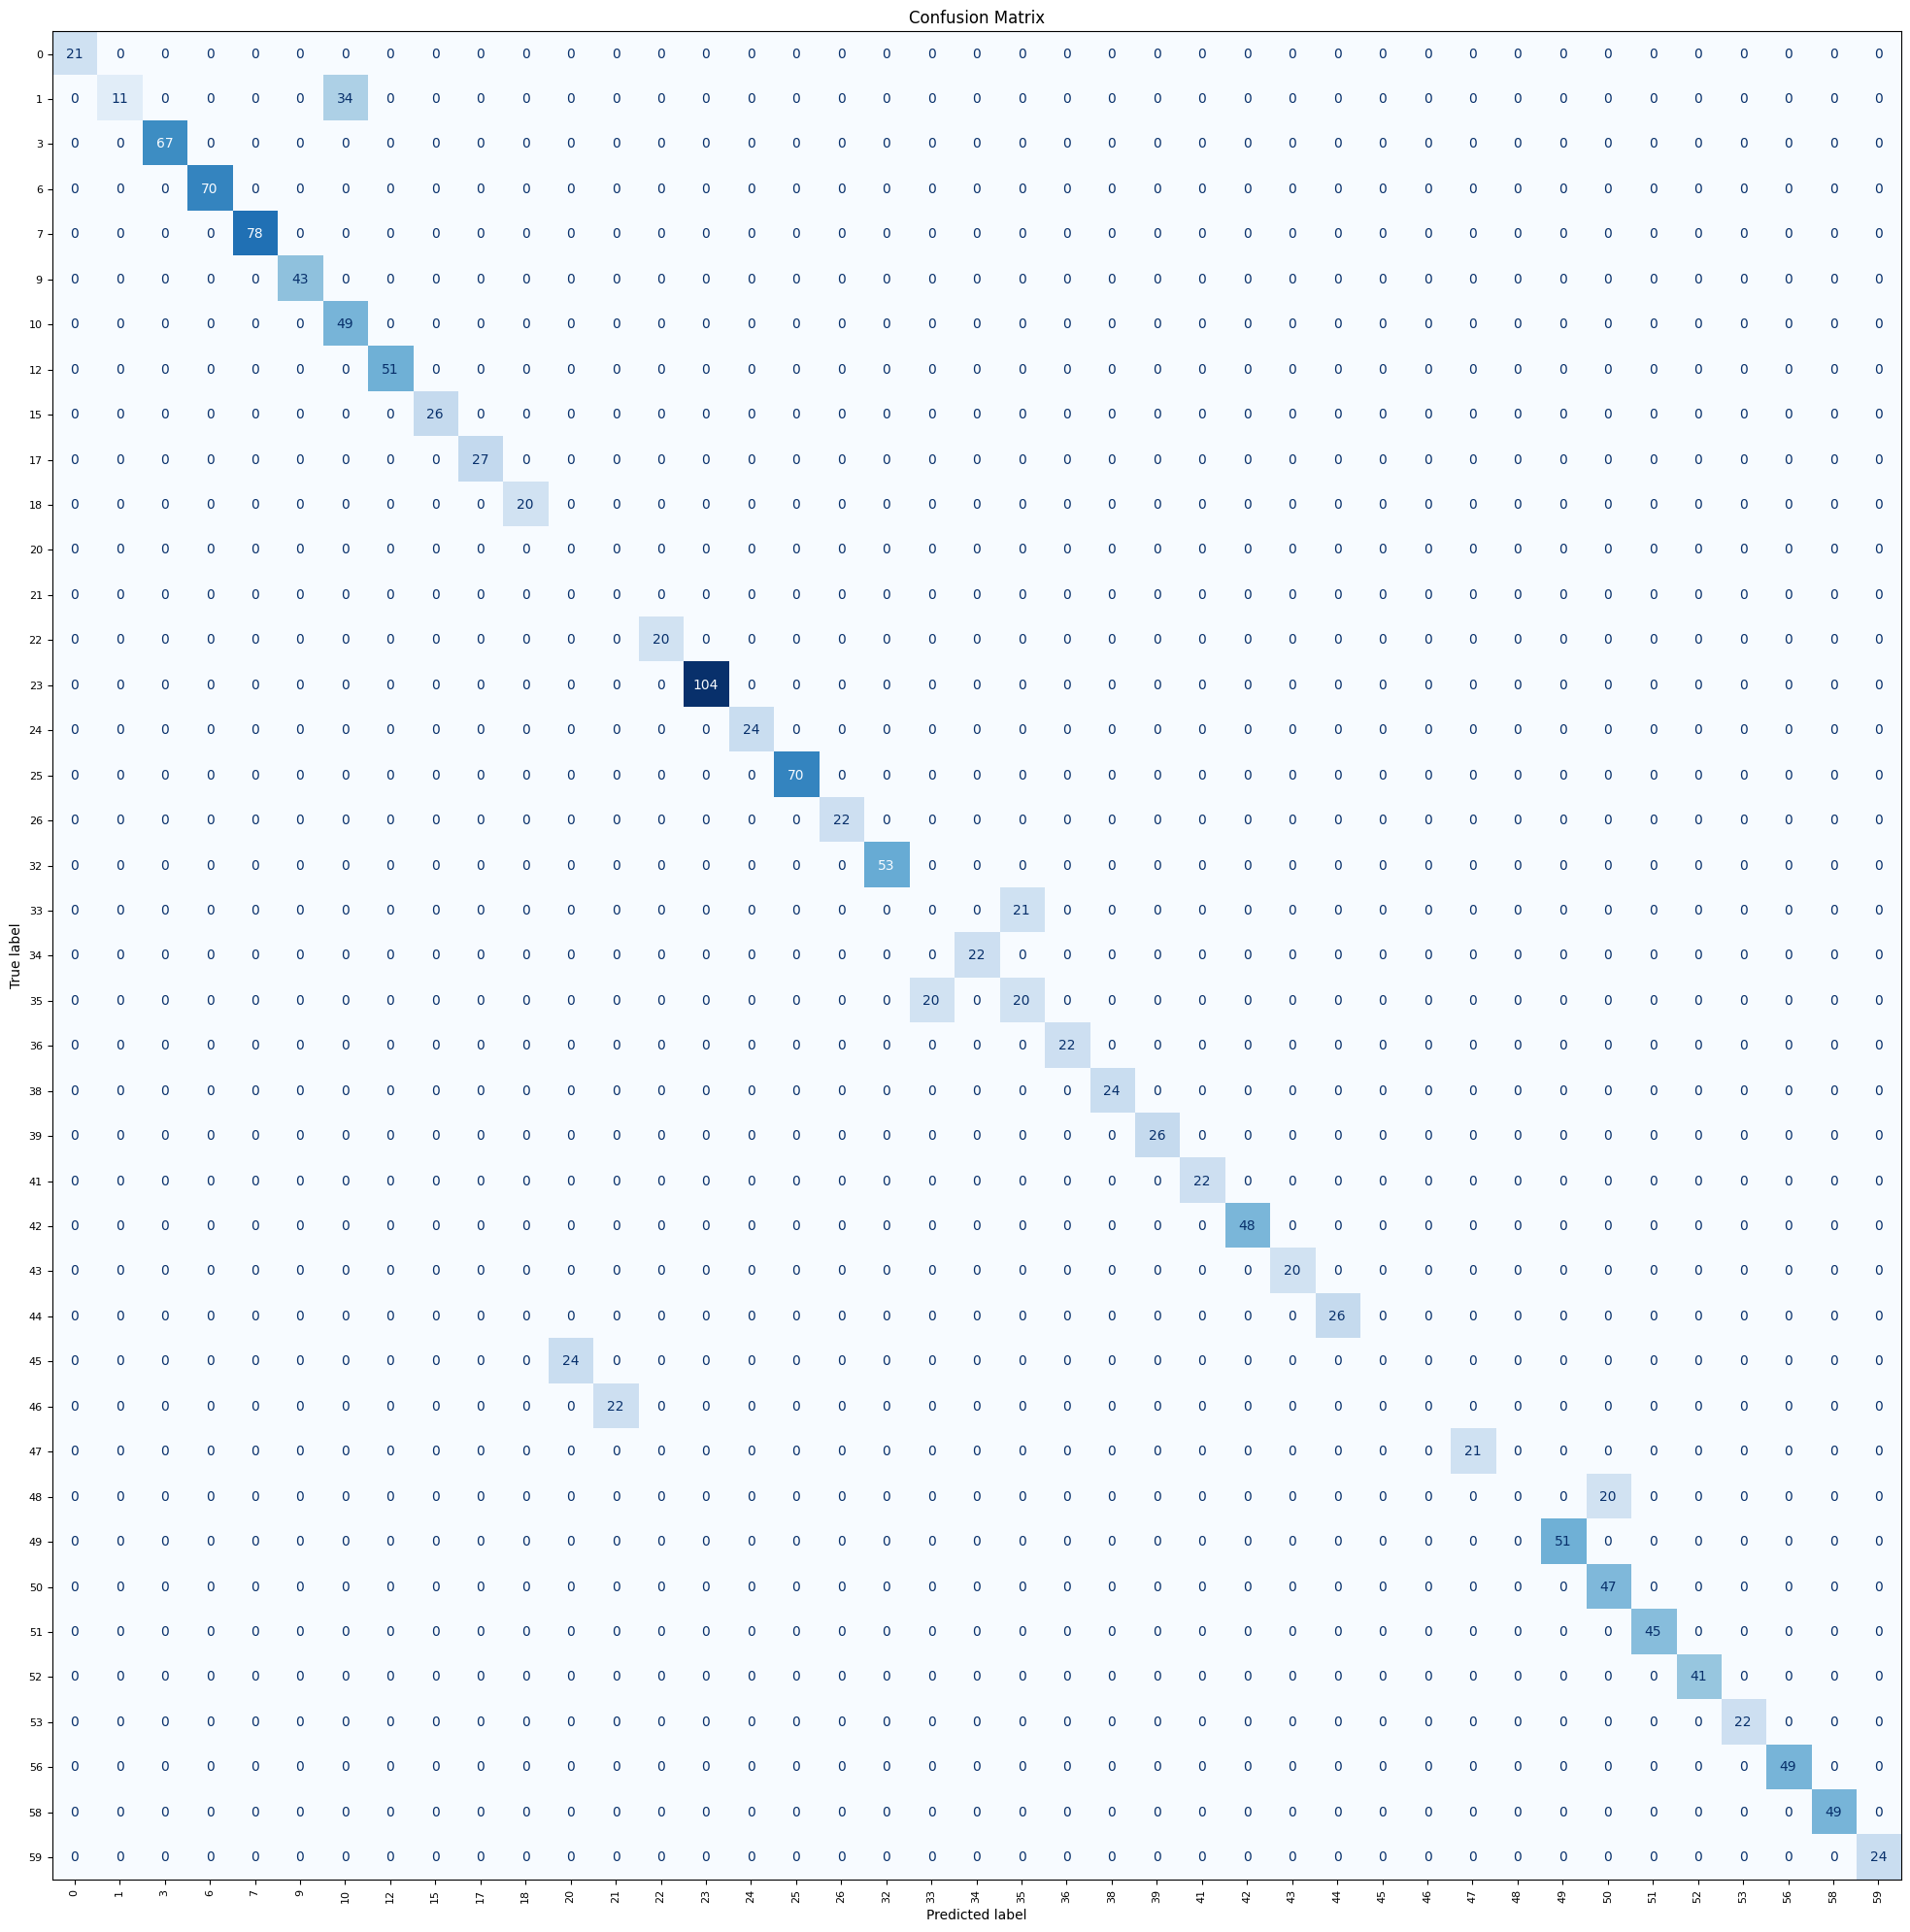

{'accuracy': 0.9044715447154471,
 'predicted_labels': array([ 0,  0,  0, ..., 59, 59, 59]),
 'true_labels': 86       0
 87       0
 88       0
 89       0
 90       0
         ..
 7875    59
 7876    59
 7877    59
 7878    59
 7879    59
 Name: genus_species_label, Length: 1476, dtype: int32}

In [23]:
print("---------------------------- EVALUACIÓN A NIVEL DE GÉNERO Y ESPECIE CON SMOTE -----------------------------------")
knn_best_smote = grid_search_for_SMOTE.best_estimator_
evaluate_knn_classifier(spectrum_test, genus_species_label_test, knn_best_smote)